## Preprocessing for Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/Customer-Churn-Records.csv')
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
df = df[df['Age'] <= 80]

### Remove features with very small correlation to Churn based on the previous EDA analysis. This will help reduce noise and prevent overfitting in our model. In addition it will take less resources

In [3]:
df = df.drop(columns=['EstimatedSalary', 'HasCrCard', 'Point Earned', 'Satisfaction Score', 'Tenure', 'CreditScore'])
df.head(5)

,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited,Complain,Card Type
0,France,Female,42,0.00,1,1,1,1,DIAMOND
1,Spain,Female,41,83807.86,1,1,0,1,DIAMOND
2,France,Female,42,159660.80,3,0,1,1,DIAMOND
3,France,Female,39,0.00,2,0,0,0,GOLD
4,Spain,Female,43,125510.82,1,1,0,0,GOLD


### Separate Categorical and Numerical variables

In [4]:
y = df['Exited']
X = df.drop(columns=['Exited', 'Complain'])

numeric_data = X.select_dtypes(include=[np.number])
categorical_data = X.select_dtypes(exclude=[np.number])

print(numeric_data.shape[1])
print(categorical_data.shape[1])

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

4
3



##### Note that I also dropped the 'Complain' column because the correlation is nearly 100%. If a customer complains our Model would just learn that means Exited, which we already know. If we included Complain in our model, it may look incredibly accurate but actually useless in practice.

### Create Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67, stratify=y
)

### Columntransformer to pipeline numerical and categorical columns

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    [
        ('categorical', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('numerical', StandardScaler(), numerical_cols)
    ]
)

## Model Selection and Tuning

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

logisticregression_pipeline = make_pipeline(
    preprocessor, LogisticRegression(class_weight='balanced')
)


In [8]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    logisticregression_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print(f"Score: {cv_results['test_score'].mean().round(3)}")
print(f"STD: {cv_results['test_score'].std().round(3)}")

Score: 0.499
STD: 0.007


#### We see a relative low score F1 score of 0.499 with a STD of 0.007 which can be expected for a Baseline Logistic Regression Model. 

### When choosing the scoring method I avoided accuracy because of the class imbalance. 

### F1 was chosen as the primary scoring because of the balance of precision and recall. Presision measures how many predicted churners actually churned, while recall measures how many actual churners were detected.

### In churn prediction, missing a churner is costly since we lose a customer we could have retained. However, flagging everyone as a churner wastes alot of resources, so this scoring method balances out the extremes making it appropriate for this issue

In [9]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    'LogisticRegression': make_pipeline(preprocessor, LogisticRegression(class_weight='balanced')),
    'Random Forest': make_pipeline(preprocessor, RandomForestClassifier(class_weight='balanced')),
    'HistGradientBoosting': make_pipeline(preprocessor, HistGradientBoostingClassifier(class_weight='balanced')),
    'XG Boosting': make_pipeline(preprocessor, XGBClassifier())
}

for name, pipeline in models.items():
    cv_results = cross_validate(pipeline, X_train, y_train, cv=10, scoring='f1')
    print(f"{name} | F1 Score: {cv_results['test_score'].mean().round(3)} | STD: {cv_results['test_score'].std().round(3)} \n ")

LogisticRegression | F1 Score: 0.503 | STD: 0.014 
 
Random Forest | F1 Score: 0.576 | STD: 0.03 
 
HistGradientBoosting | F1 Score: 0.609 | STD: 0.022 
 
XG Boosting | F1 Score: 0.594 | STD: 0.036 
 


### Based on my initial cross-validation results, HistGradientBoosting and XG Boosting received the highest scores among baseline models. So I will choose these models for hyperparameter tuning to find the best overall model

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

param_grid = {
    'histgradientboostingclassifier__max_depth': randint(3, 8),
    'histgradientboostingclassifier__max_leaf_nodes': randint(8, 256),
    'histgradientboostingclassifier__learning_rate': loguniform(0.01, 0.3)
}

hgb_pipeline = make_pipeline(
    preprocessor,
    HistGradientBoostingClassifier(max_iter=1000, early_stopping=True)
)

hgb_random_search = RandomizedSearchCV(
    hgb_pipeline,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='f1'
)

hgb_random_search.fit(X_train, y_train)
hgb_random_search.best_params_

{'histgradientboostingclassifier__learning_rate': np.float64(0.07981040807441829),
 'histgradientboostingclassifier__max_depth': 5,
 'histgradientboostingclassifier__max_leaf_nodes': 167}

In [11]:
cv_results = cross_validate(
    hgb_random_search.best_estimator_,
    X_train,
    y_train,
    cv=10,
    scoring='f1'
)

print(f"Avg ScoreL: {cv_results['test_score'].mean().round(3)}")
print(f"STD: {cv_results['test_score'].std().round(3)}")


Avg ScoreL: 0.59
STD: 0.037


In [12]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = make_pipeline(
    preprocessor,
    XGBClassifier(
        n_estimators=1000,
        scale_pos_weight=scale_pos_weight,
    )
)

param_grid = {
    'xgbclassifier__learning_rate': loguniform(0.01, 0.3),
    'xgbclassifier__max_depth': randint(3, 8),
    'xgbclassifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_grid,
    n_iter=20,
    cv=5,
    scoring='f1'
)

xgb_random_search.fit(X_train, y_train)

print(xgb_random_search.best_params_)

{'xgbclassifier__learning_rate': np.float64(0.01461883632067483), 'xgbclassifier__max_depth': 7, 'xgbclassifier__subsample': 0.6}


In [13]:
cv_results = cross_validate(
    xgb_random_search.best_estimator_,
    X_train,
    y_train,
    cv=10,
    scoring='f1'
)

print(f"Avg Score: {cv_results['test_score'].mean().round(3)}")
print(f"STD: {cv_results['test_score'].std().round(3)}")

Avg Score: 0.611
STD: 0.027


### After tuning the Hyperparameters of HistGradientBoosting and XGBoost using randomizedSearchCV there was very minimal improvements, suggesting the default parameters were nearly optimal for this dataset.

### I selected XGBoost as the final model despite HistGradientBoosting having a stronger baseline average score and std. XGBoost responded better to hyperparameter tuning, improving from 0.594 to 0.61. Both models had about the same stability (STD: 0.022) but because of XGBoost's slight improvements I believe it has more room to optimize for this data set. 

In [14]:
print(f"{xgb_random_search.predict_proba(X_test)}\n")
print(xgb_random_search.predict(X_test))

X_test_copy = X_test.copy()
X_test_copy['churn_probability'] = xgb_random_search.predict_proba(X_test)[:, 1]
X_test_copy['predicted_churn'] = xgb_random_search.predict(X_test)
X_test_copy['actual_churn'] = y_test.values
X_test_copy.head(10)

[[0.16721886 0.83278114]
 [0.01336473 0.98663527]
 [0.04881287 0.95118713]
 ...
 [0.46016413 0.5398359 ]
 [0.01261461 0.9873854 ]
 [0.5111502  0.48884982]]

[1 1 1 ... 1 1 0]


,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Card Type,churn_probability,predicted_churn,actual_churn
3982,France,Male,46,0.00,1,0,DIAMOND,0.832781,1,1
297,Spain,Female,44,0.00,3,0,SILVER,0.986635,1,1
3229,France,Female,66,0.00,1,0,GOLD,0.951187,1,1
554,Germany,Male,33,129834.67,1,0,SILVER,0.156712,0,0
4076,France,Female,50,0.00,1,0,GOLD,0.975547,1,1
5012,France,Male,40,0.00,2,1,PLATINUM,0.077124,0,0
4778,Spain,Female,45,0.00,2,1,GOLD,0.023802,0,0
1915,Spain,Male,25,0.00,1,1,SILVER,0.063201,0,0
5186,France,Male,32,0.00,2,0,GOLD,0.023619,0,0
5158,France,Male,55,0.00,1,0,GOLD,0.971577,1,0


In [15]:
high_risk = X_test_copy[X_test_copy['churn_probability'] > 0.7]
print(f"Amount of High Risk customers: {len(high_risk)}")
print(f"Percent of High Risk customers: {(len(high_risk)/len(X_test_copy))*100:.2f}%")

Amount of High Risk customers: 333
Percent of High Risk customers: 16.67%


In [16]:
print(f"Churn Rate by Geography:\n{X_test_copy.groupby('Geography')['predicted_churn'].mean().sort_values(ascending=False) * 100}\n")

Churn Rate by Geography:
Geography
Germany    43.667297
France     20.429009
Spain      20.000000
Name: predicted_churn, dtype: float64



### Customers from Germany have the highest Churn Rate at 44.42% 
### More than double the proportion of France and Spain, both hovering around 20%

In [17]:
print(f"Churn Rate by Gender:\n{X_test_copy.groupby('Gender')['predicted_churn'].mean().sort_values(ascending=False) * 100}\n")

Churn Rate by Gender:
Gender
Female    33.368644
Male      20.303605
Name: predicted_churn, dtype: float64



### Female customers are 1.65 times more likely to Churn compared to Male customers

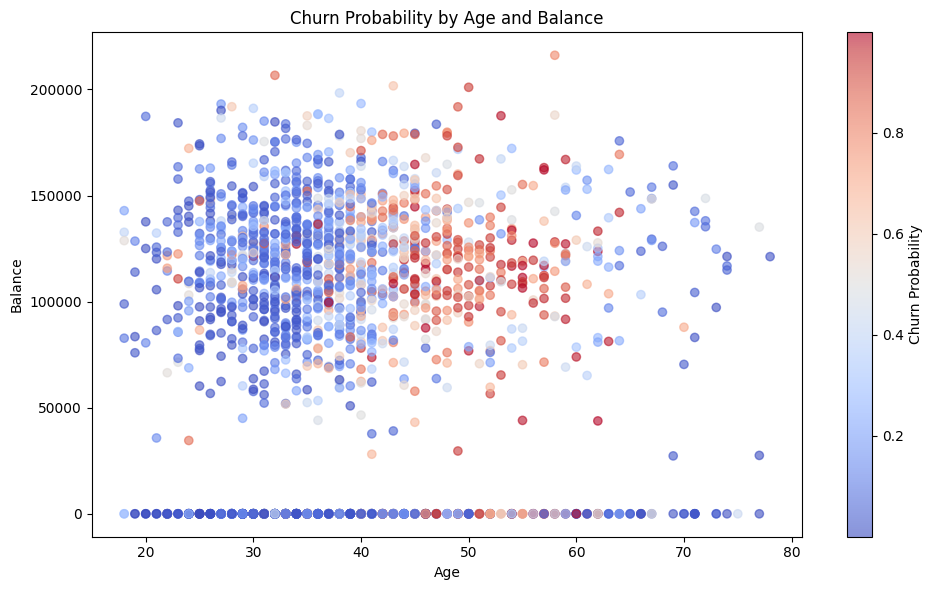

Characteristics of High Risk Customers
Average Age: 46.62
Average Balance: 92678.28
Age Range (25th-75th percentile): 42 - 52
Balance Range (25th-75th percentile): 65407 - 128353


In [20]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=X_test_copy['Age'],
    y=X_test_copy['Balance'],
    c=X_test_copy['churn_probability'],
    cmap='coolwarm',
    alpha=0.6
)

plt.colorbar(scatter, label='Churn Probability')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Churn Probability by Age and Balance')
plt.tight_layout()
plt.show()

print("Characteristics of High Risk Customers")
print(f"Average Age: {high_risk['Age'].mean():.2f}")
print(f"Average Balance: {high_risk['Balance'].mean():.2f}")
print(f"Age Range (25th-75th percentile): {high_risk['Age'].quantile(0.25):.0f} - {high_risk['Age'].quantile(0.75):.0f}")
print(f"Balance Range (25th-75th percentile): {high_risk['Balance'].quantile(0.25):.0f} - {high_risk['Balance'].quantile(0.75):.0f}")

In [19]:
print(f"Churn Rate by Number of Products:\n{X_test_copy.groupby('NumOfProducts')['predicted_churn'].mean().sort_values(ascending=False) * 100}\n")
print(f"Count of Each Product by Customer{X_test_copy['NumOfProducts'].value_counts().sort_index()}\n")

print(f"Churn Rate by Card Type:\n{X_test_copy.groupby('Card Type')['predicted_churn'].mean().sort_values(ascending=False) * 100}\n")

Churn Rate by Number of Products:
NumOfProducts
4    100.000000
3     95.918367
1     39.289240
2      8.288482
Name: predicted_churn, dtype: float64

Count of Each Product by CustomerNumOfProducts
1    1013
2     929
3      49
4       7
Name: count, dtype: int64

Churn Rate by Card Type:
Card Type
DIAMOND     27.169811
SILVER      26.264591
GOLD        26.215645
PLATINUM    26.195426
Name: predicted_churn, dtype: float64



### Customers with 3 and 4 products have an extremely high churn rate with 95.9% and 100% respectively. However with sample sizes of only 49 and 7 customers out of 3000, these results are statistically insignificant. 

### But customers with 1 product are 39.29% likely to churn while customers with 2 products are only 8.29% likely to churn. With both having sample sizes of about 1000, we can conlude customers with 2 products are nearly 5 times less likely to churn

### All 4 types of cards have about the same likelihood of churning of approx 26-27%

# Reccomendations Based on Model Analysis

## 1. German Market
### The model predicts that German customers are over 2 times more likely to churn compared to France and Spain with a 44.4% predicted churn rate. Before making any changes I believe the bank should investigate the cause of these issues. Is there more banking competition in Germany, are there any quality issues, or even economic conditions playing a role? The model can identify where the issue is concentrated, but not the root cause.

## 2. Female Customer Retention
### Female customers showed a predicted churn rate of 33.9% compared to 20.5% for male customers, making them over 1.65 times more likely to churn. This suggests the bank's current products, communication, and/or service experience is better alligned with male customers. Similar to the issue in Germany, it's reccomended to do some research into the female customer experience. Looking for potential gender bias or different customer service interactions that may be causing this discrepancy.

## 3. Customer Churn by Amount of Products
### Single product customers churn at 40.8% compared to just 7.4% for two product customers. This finding is the most actionable in this analysis. Customers with only one product have very little attachment to the bank and don't lose much when leaving. The bank should implement systems that flag single customer users after a fixed amount of time, around 6 months and offer them another product at a discounted rate. These offers would be slight loss-leaders but would encourage customers to have more connection to the bank leading to more loyal customers and revenue overtime. 

## 4. High Risk Customers (Middle Aged and High Balance)
### Middle aged customers(approx 43-52) with high balances are likely in their peak earning years, making them attractive prospects for other banks who will offer premium rates and services. This is reflected in the majority of High Risk customers falling into these averages. Having likely built a long term relationship with the bank, their decision to leave not only represents a loss in revenue but a failure to retain customers at their most financially valuable stage of life. To fix this issue the bank should implement retention strategies such as personalized loyalty programs, competitive interest rates, and proactive customer outreach to strengthen long term trust. These should be done before ANY potential dissatisfaction rather than being a reactive measure. 

## Limitations 
### There are several limitations with the data and analysis. The model explains who is likely to churn but not why, root cause analysis would need to be performed with qualitative research outside of this dataset. The dataset is missing some possibly strong predictive features such as transaction history, app usage frequency, customer service interaction history, and time since last product purchase. These features would likely improve the model performance over the current F1 score of 0.61. Also the threshold of 0.7 likelihood of churning used to define high risk customers was chosen conservatively. Threshold tuning based on the bank's retention campaign budget and cost per intervention could further optimize the tradeoff between recall and precision. Finally, customers with 3-4 products warrant further investigation with larger sample before drawing any conclusions.

